In [ ]:
import json
import csv
from pathlib import Path

INPUT_JSON = "../../data/outputs/run_20260414_004119/campaign_1/analysis_evaluation_results.json"
OUTPUT_CSV = "../../data/outputs/run_20260414_004119/comparsion_results/analysis_comparson_result.csv"



In [ ]:
def ReadJsonAndWriteCsv():
    input_path = Path(INPUT_JSON)
    if not input_path.exists():
        raise FileNotFoundError(f"File not found: {INPUT_JSON}")

    with open(input_path, "r", encoding="utf-8") as f:
        data = json.load(f)

    scores = data.get("scores", {})

    row = {
        "clarity": scores.get("clarity"),
        "accuracy": scores.get("accuracy"),
        "structure": scores.get("structure"),
        "overall": scores.get("overall"),
    }

    with open(OUTPUT_CSV, "a", newline="", encoding="utf-8") as f:
        writer = csv.DictWriter(
            f,
            fieldnames=["clarity", "accuracy", "structure", "overall", "verdict"]
        )
        writer.writerow(row)
    print(f"Saved CSV to: {OUTPUT_CSV}")
    print("Extracted data:", row)

In [4]:
ReadJsonAndWriteCsv()

Saved CSV to: ../../data/outputs/run_20260414_004119/comparsion_results/comparson_result.csv
Extracted data: {'clarity': 2, 'accuracy': 2, 'structure': 2, 'overall': 2.0}


In [10]:
import matplotlib.pyplot as plt
import pandas as pd

In [ ]:


def plot_metrics(csv_path: str):
    df = pd.read_csv(csv_path)

    # normalize version names
    df["version"] = df["version"].str.lower()

    metrics = ["clarity", "accuracy", "structure","overall"]

    for metric in metrics:
        plt.figure(figsize=(6, 4))

        plt.bar(df["version"], df[metric])

        plt.title(f"{metric.capitalize()} Comparison Across Versions")
        plt.xlabel("Version")
        plt.ylabel("Score")
        plt.ylim(0, 3.2)

        plt.tight_layout()
        plt.show()

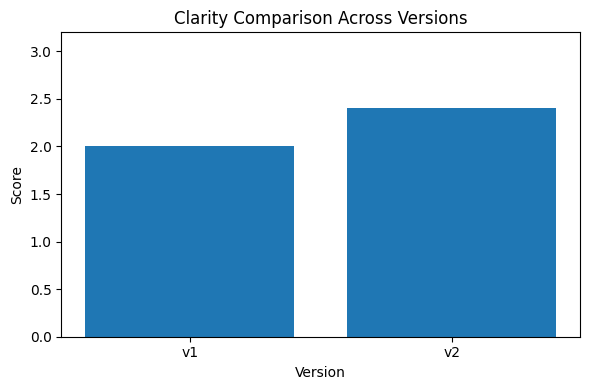

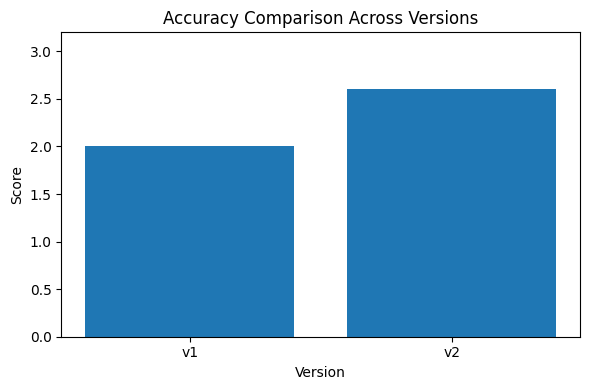

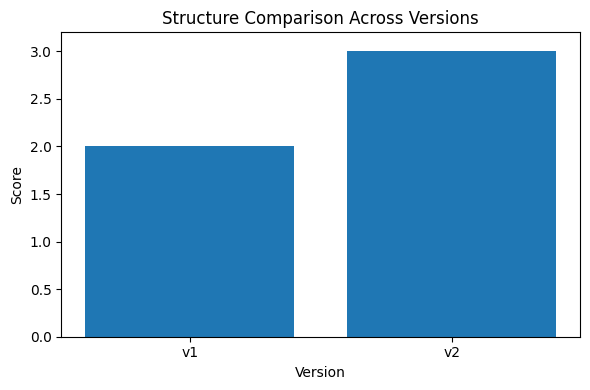

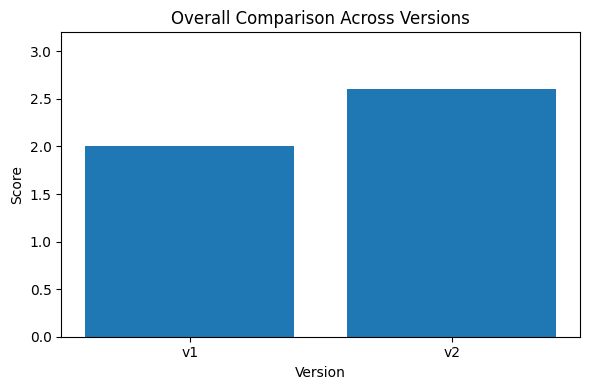

In [17]:
plot_metrics(OUTPUT_CSV)